ROOT exists: True  -> C:\Users\hyeon\Documents\miniconda_medimg_env\data\lumbar-coordinate
DATA_DIR exists: True  -> C:\Users\hyeon\Documents\miniconda_medimg_env\data\lumbar-coordinate\data

-- Top-level items inside /data/:
DIR  - processed_lsd
DIR  - processed_lsd_jpgs
DIR  - processed_osf
DIR  - processed_osf_jpgs
DIR  - processed_spider
DIR  - processed_spider_jpgs
DIR  - processed_tseg
DIR  - processed_tseg_jpgs

Discovered 2474 image index entries (basename and relative paths combined).

=== coords_pretrain.csv : Shape (5605, 7) ===
Columns: ['filename', 'source', 'x', 'y', 'level', 'relative_x', 'relative_y']

Head:


,filename,source,x,y,level,relative_x,relative_y
0,1_t2.jpg,spider,139,175,L5/S1,0.542969,0.683594
1,1_t2.jpg,spider,133,157,L4/L5,0.519531,0.613281
2,1_t2.jpg,spider,132,131,L3/L4,0.515625,0.511719
3,1_t2.jpg,spider,131,102,L2/L3,0.511719,0.398438
4,1_t2.jpg,spider,134,84,L1/L2,0.523438,0.328125
5,2_t2.jpg,spider,143,179,L5/S1,0.558594,0.699219
6,2_t2.jpg,spider,129,154,L4/L5,0.503906,0.601562
7,2_t2.jpg,spider,123,125,L3/L4,0.480469,0.488281
8,2_t2.jpg,spider,123,91,L2/L3,0.480469,0.355469
9,2_t2.jpg,spider,127,59,L1/L2,0.496094,0.230469



Missing values per column:


filename      0
source        0
x             0
y             0
level         0
relative_x    0
relative_y    0
dtype: int64


Basic dtypes:


...

Unnamed: 0         0
series_id          0
relative_x         0
relative_y         0
condition          0
side               0
instance_number    0
study_id           0
level              0
dtype: int64


Basic dtypes:


Unnamed: 0           int64
series_id            int64
relative_x         float64
relative_y         float64
condition           object
side                object
instance_number      int64
study_id             int64
level               object
dtype: object

All referenced images in coords_pretrain.csv found on disk.
coords_rsna_improved.csv: unique series_id = 6291 (no direct on-disk image validation performed)

Saved issues report to: C:\Users\hyeon\Documents\miniconda_medimg_env\data\lumbar-coordinate\_audit_outputs\data_audit_issues.csv


""


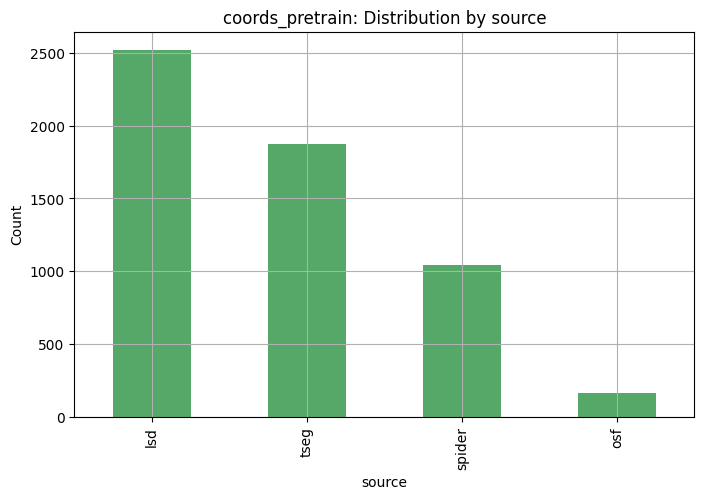

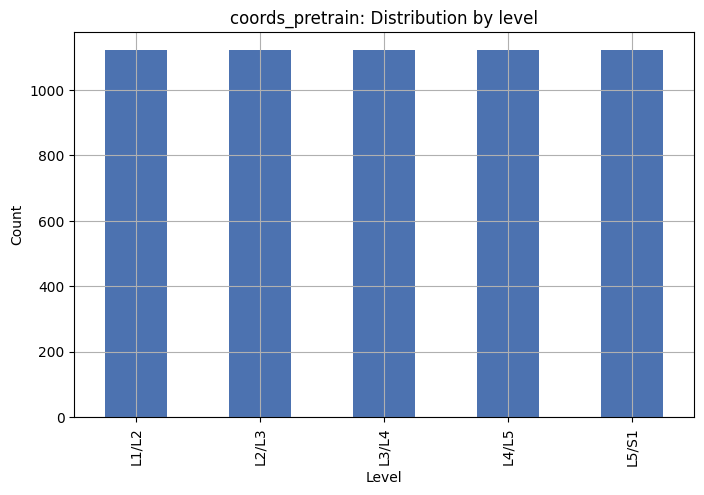

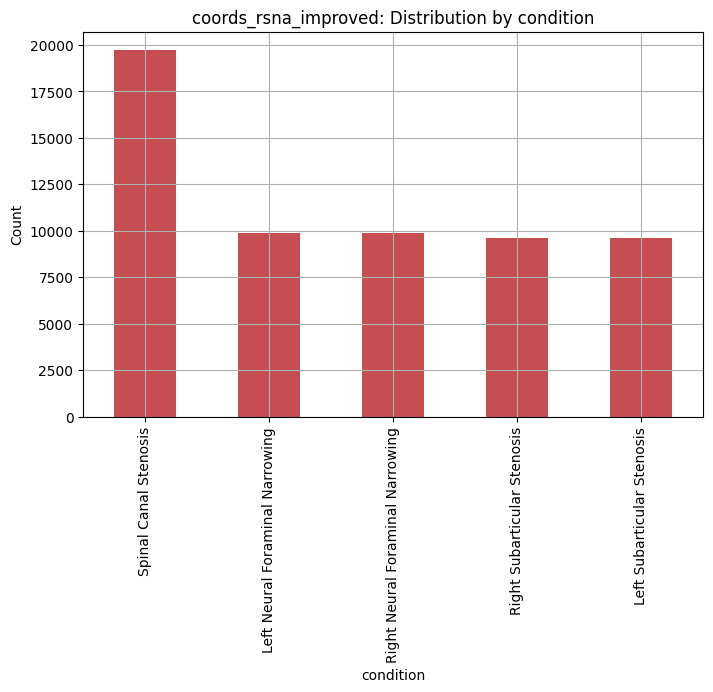

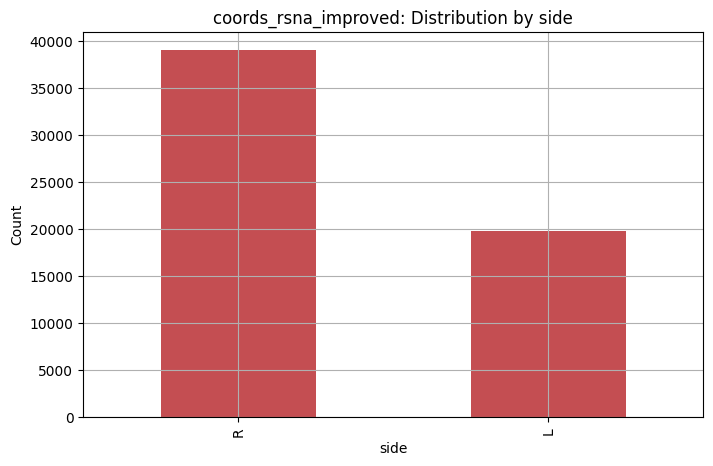

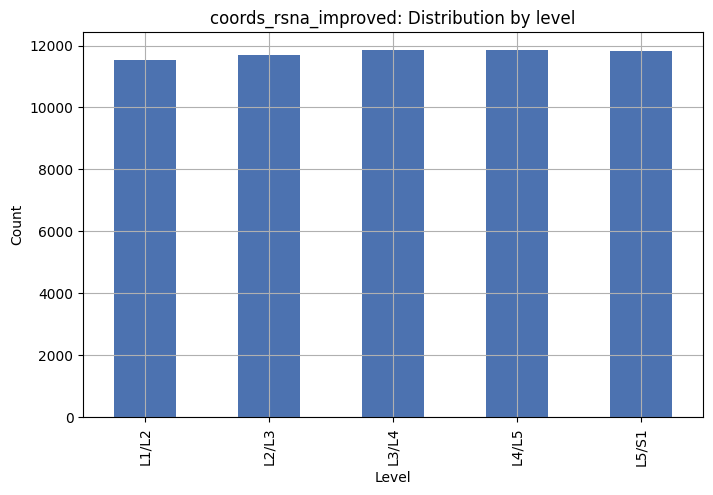

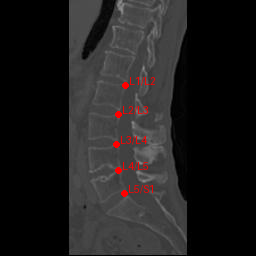

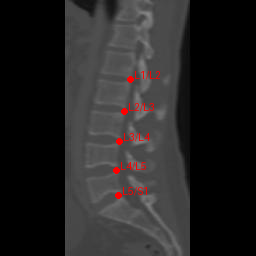

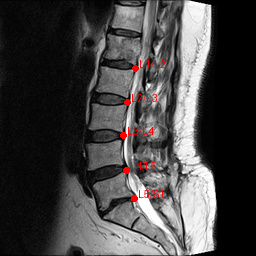

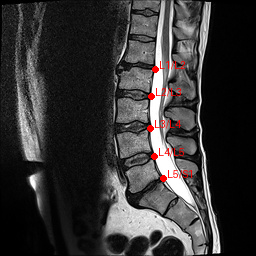

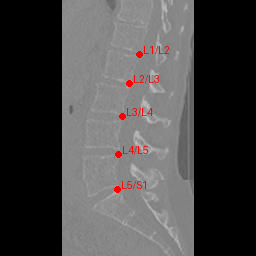

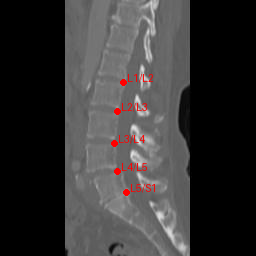

,type,key,n,has_all_5_levels
0,levels_per_image,0001.jpg,5,True
1,levels_per_image,0002.jpg,5,True
2,levels_per_image,0003.jpg,5,True
3,levels_per_image,0004.jpg,5,True
4,levels_per_image,0005.jpg,5,True
5,levels_per_image,0006.jpg,5,True
6,levels_per_image,0007.jpg,5,True
7,levels_per_image,0008.jpg,5,True
8,levels_per_image,0009.jpg,5,True
9,levels_per_image,0010.jpg,5,True


Artifacts saved to: C:\Users\hyeon\Documents\miniconda_medimg_env\data\lumbar-coordinate\_audit_outputs


In [1]:
# %% [markdown]
# # Lumbar-Coordinate Dataset Audit & Quick EDA
# Paths adapted for Windows. This notebook:
# 1) inventories the /data/ folder;
# 2) audits coords_pretrain.csv / coords_rsna_improved.csv;
# 3) checks filename/series references against on-disk files where possible;
# 4) visualizes a few images with annotated points from coords_pretrain.csv;
# 5) summarizes distributions and saves an audit report.

# %%
import os
from pathlib import Path
import sys
import json
import random
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Make plots readable
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# ---- Configuration ----
ROOT = Path(r"C:/Users/hyeon/Documents/miniconda_medimg_env/data/lumbar-coordinate")
DATA_DIR = ROOT / "data"
CSV_PRETRAIN = ROOT / "coords_pretrain.csv"
CSV_RSNA = ROOT / "coords_rsna_improved.csv"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# If images are nested, list of candidate image extensions:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# Output artifacts
OUT_DIR = ROOT / "_audit_outputs"
OUT_DIR.mkdir(exist_ok=True, parents=True)
ISSUES_CSV = OUT_DIR / "data_audit_issues.csv"

# %%
def walk_images(base_dir: Path, exts=IMG_EXTS):
    """
    Walk base_dir and return a dict: {relative_path_str_lower: absolute_path}.
    Relative path is relative to DATA_DIR to facilitate matching.
    """
    mapping = {}
    if not base_dir.exists():
        return mapping
    for root, dirs, files in os.walk(base_dir):
        for fn in files:
            ext = Path(fn).suffix.lower()
            if ext in exts:
                abs_path = Path(root) / fn
                rel = abs_path.relative_to(base_dir).as_posix()  # keep forward slashes
                mapping[rel.lower()] = abs_path
                mapping[Path(fn).name.lower()] = abs_path  # also index by basename only
    return mapping

def quick_df_report(df: pd.DataFrame, name: str):
    print(f"\n=== {name} : Shape {df.shape} ===")
    print("Columns:", list(df.columns))
    print("\nHead:")
    display(df.head(10))
    print("\nMissing values per column:")
    display(df.isna().sum())
    print("\nBasic dtypes:")
    display(df.dtypes)

def summarize_levels(df, level_col="level", title="Distribution by lumbar level"):
    if level_col not in df.columns:
        print(f"[skip] '{level_col}' not found.")
        return
    counts = df[level_col].value_counts().sort_index()
    ax = counts.plot(kind="bar", color="#4C72B0", title=title)
    ax.set_xlabel("Level"); ax.set_ylabel("Count")
    plt.show()

def overlay_points_on_image(img_path: Path, points, color=(255, 0, 0), radius=3):
    im = Image.open(img_path).convert("RGB")
    w, h = im.size
    draw = ImageDraw.Draw(im)
    for (rx, ry, label) in points:
        x = float(rx) * w
        y = float(ry) * h
        draw.ellipse((x-radius, y-radius, x+radius, y+radius), fill=color, outline=color)
        if label:
            draw.text((x+4, y-10), label, fill=color)
    return im

# %% [markdown]
# ## 1) Inventory `/data/` folder

# %%
print(f"ROOT exists: {ROOT.exists()}  -> {ROOT}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}  -> {DATA_DIR}")

subdirs = []
files_top = []
if DATA_DIR.exists():
    for p in DATA_DIR.iterdir():
        if p.is_dir():
            subdirs.append(p)
        else:
            files_top.append(p)

print("\n-- Top-level items inside /data/:")
for p in sorted(subdirs + files_top):
    print("DIR " if p.is_dir() else "FILE", "-", p.name)

# Deep inventory of images
image_map = walk_images(DATA_DIR, IMG_EXTS)
print(f"\nDiscovered {len(image_map)} image index entries (basename and relative paths combined).")
# Note: image_map is indexed by lowercased keys to allow case-insensitive matches.

# %% [markdown]
# ## 2) Load & sanity-check CSVs

# %%
issues = []

# Load coords_pretrain.csv
if CSV_PRETRAIN.exists():
    df_pre = pd.read_csv(CSV_PRETRAIN)
    quick_df_report(df_pre, "coords_pretrain.csv")

    # Expected columns from dataset description
    expected_pre = {"filename","source","x","y","level","relative_x","relative_y"}
    missing_cols_pre = expected_pre - set(df_pre.columns)
    if missing_cols_pre:
        issues.append({"file":"coords_pretrain.csv","issue":"missing_columns","detail":",".join(sorted(missing_cols_pre))})
else:
    df_pre = pd.DataFrame()
    print(f"[WARN] Missing file: {CSV_PRETRAIN}")
    issues.append({"file":"coords_pretrain.csv","issue":"file_missing","detail":str(CSV_PRETRAIN)})

# Load coords_rsna_improved.csv
if CSV_RSNA.exists():
    df_rsna = pd.read_csv(CSV_RSNA)
    quick_df_report(df_rsna, "coords_rsna_improved.csv")

    # Minimal columns we expect based on shared schema
    expected_rsna_min = {"series_id","relative_x","relative_y","level"}
    missing_cols_rsna = expected_rsna_min - set(df_rsna.columns)
    if missing_cols_rsna:
        issues.append({"file":"coords_rsna_improved.csv","issue":"missing_columns","detail":",".join(sorted(missing_cols_rsna))})
else:
    df_rsna = pd.DataFrame()
    print(f"[WARN] Missing file: {CSV_RSNA}")
    issues.append({"file":"coords_rsna_improved.csv","issue":"file_missing","detail":str(CSV_RSNA)})

# %% [markdown]
# ## 3) Linkage checks (CSV → images on disk)
# - For `coords_pretrain.csv`, we expect `filename` image(s) to be under `/data/`.
# - We match by basename and also try subfolder relative paths, case-insensitive.

# %%
def check_filenames_exist(df, filename_col="filename", label="coords_pretrain.csv"):
    if df.empty or filename_col not in df.columns:
        print(f"[skip] {label} filename checks.")
        return pd.DataFrame(columns=["file","issue","detail"])
    missing = []
    for fn in sorted(set(df[filename_col].astype(str))):
        key = fn.strip().lower()
        if key not in image_map:
            # try only basename in case CSV contains paths
            base = Path(fn).name.lower()
            if base not in image_map:
                missing.append(fn)
    if missing:
        print(f"[WARN] {len(missing)} files referenced in {label} not found under /data/. Showing up to 30:")
        for m in missing[:30]:
            print("  -", m)
    else:
        print(f"All referenced images in {label} found on disk.")
    return pd.DataFrame([{"file":label, "issue":"missing_image", "detail":m} for m in missing])

issues_df_list = []
issues_df_list.append(check_filenames_exist(df_pre, "filename", "coords_pretrain.csv"))

# RSNA mapping note:
# coords_rsna_improved.csv typically refers to 'series_id'/'study_id' from DICOM series rather than .jpg basenames.
# Without a DICOM archive crosswalk, we only perform structural checks here.
if not df_rsna.empty and "series_id" in df_rsna.columns:
    n_unique_series = df_rsna["series_id"].nunique()
    print(f"coords_rsna_improved.csv: unique series_id = {n_unique_series} (no direct on-disk image validation performed)")
else:
    print("[skip] RSNA: no series_id column / empty dataframe.")

# Aggregate issues so far
issues_df = pd.concat([d for d in issues_df_list if d is not None], ignore_index=True)
if issues:
    issues_df = pd.concat([issues_df, pd.DataFrame(issues)], ignore_index=True)
issues_df.to_csv(ISSUES_CSV, index=False)
print(f"\nSaved issues report to: {ISSUES_CSV}")
display(issues_df.head(20))

# %% [markdown]
# ## 4) Quick distributions

# %%
if not df_pre.empty:
    # source distribution (if present)
    if "source" in df_pre.columns:
        ax = df_pre["source"].value_counts().plot(kind="bar", color="#55A868",
                                                  title="coords_pretrain: Distribution by source")
        ax.set_xlabel("source"); ax.set_ylabel("Count")
        plt.show()
    summarize_levels(df_pre, level_col="level", title="coords_pretrain: Distribution by level")

if not df_rsna.empty:
    # condition / side distributions (if present)
    for col in ["condition","side"]:
        if col in df_rsna.columns:
            ax = df_rsna[col].value_counts().plot(kind="bar", color="#C44E52",
                                                  title=f"coords_rsna_improved: Distribution by {col}")
            ax.set_xlabel(col); ax.set_ylabel("Count")
            plt.show()
    summarize_levels(df_rsna, level_col="level", title="coords_rsna_improved: Distribution by level")

# %% [markdown]
# ## 5) Visual sanity check: overlay a few landmarks on images (pretrain CSV)
# We will use normalized coordinates (relative_x, relative_y) to avoid needing actual width/height metadata.
# If an image key is not found, it will be skipped.

# %%
def try_show_samples(df, n_images=4):
    if df.empty:
        print("[skip] No data available for visualization.")
        return
    # sample distinct filenames that exist on disk
    files = list(dict.fromkeys(df["filename"].astype(str)))
    random.shuffle(files)
    shown = 0
    for fn in files:
        key = fn.strip().lower()
        base = Path(fn).name.lower()
        abs_path = image_map.get(key) or image_map.get(base)
        if abs_path and abs_path.exists():
            subset = df[df["filename"] == fn]
            if {"relative_x","relative_y"}.issubset(subset.columns):
                pts = [(row["relative_x"], row["relative_y"], row.get("level", "")) 
                       for _, row in subset.iterrows()]
                try:
                    im = overlay_points_on_image(abs_path, pts, color=(255,0,0), radius=3)
                    display(im)
                    shown += 1
                except Exception as e:
                    print(f"[viz] Failed for {fn}: {e}")
        if shown >= n_images:
            break
    if shown == 0:
        print("No eligible images found for visualization (check paths under /data/).")

try_show_samples(df_pre, n_images=6)

# %% [markdown]
# ## 6) Light integrity checks (duplicates, per-image completeness)

# %%
def per_image_checks(df, fname_col="filename", level_col="level"):
    rows = []
    if df.empty or fname_col not in df.columns or level_col not in df.columns:
        return pd.DataFrame(columns=["type","key","n"])
    grp = df.groupby(fname_col)
    for k, g in grp:
        levels = list(g[level_col])
        level_counts = Counter(levels)
        rows.append({"type":"levels_per_image", "key":k, "n":len(levels),
                     "has_all_5_levels": set(level_counts.keys()) == {"L1/L2","L2/L3","L3/L4","L4/L5","L5/S1"}})
        # duplicates at same level?
        dup = [lvl for lvl, c in level_counts.items() if c > 1]
        if dup:
            rows.append({"type":"duplicate_levels", "key":k, "n":len(dup), "detail":",".join(dup)})
    return pd.DataFrame(rows)

if not df_pre.empty:
    qc_pre = per_image_checks(df_pre, "filename", "level")
    display(qc_pre.head(20))
    qc_pre.to_csv(OUT_DIR / "qc_pretrain_per_image.csv", index=False)

# %% [markdown]
# ## 7) Save trimmed previews for quick manual review

# %%
if not df_pre.empty:
    df_pre.head(100).to_csv(OUT_DIR / "coords_pretrain_head100.csv", index=False)
if not df_rsna.empty:
    df_rsna.head(100).to_csv(OUT_DIR / "coords_rsna_head100.csv", index=False)

print("Artifacts saved to:", OUT_DIR)